In [21]:
from matplotlib import pyplot as plt
# from brokenaxes import brokenaxes
import numpy as np
import os
import sys
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

my_figsize = [20, 12]
my_fontsize = 75
WIDTH = 0.05  # the width of the bars
SHORT = 100001 # 100KB
LONG = 1000000 # 1000KB
METRICS = ['FCT', 'GOODPUT']

os.chdir(sys.path[0])
os.chdir('./')

SCHEMES = [
    "../../Ideal/DATA/NSDI25/Onepod/Incast",
    "../../zeropod-singlepod/DATA/NSDI25/ost=5/incast/ppt_16_topk_16",
    "../../ESN/DATA/NSDI25/singlepod/incast", 
    ]
workloads = ["incast_30", "incast_55", "incast_80", "incast_105", "incast_130", "incast_155", "incast_180", "incast_205", "incast_230", "incast_255"]
incast_degree = [30, 55, 80, 105, 130, 155, 180, 205, 230, 255]

DATA_DIR_TEMP = '{scheme}/DATA_zeropod_{workload}/'

data = {}
for scheme in SCHEMES:
    data[scheme] = {}
    for workload in workloads:
        data[scheme][workload] = {}
    
for scheme in SCHEMES:
    for workload in workloads:
        dir_path = DATA_DIR_TEMP.format(scheme=scheme, workload=workload)
        data[scheme][workload]['PATH'] = dir_path
        for metric in METRICS:
            data_path = dir_path + metric + '.txt'
            data[scheme][workload][metric] = np.loadtxt(data_path)

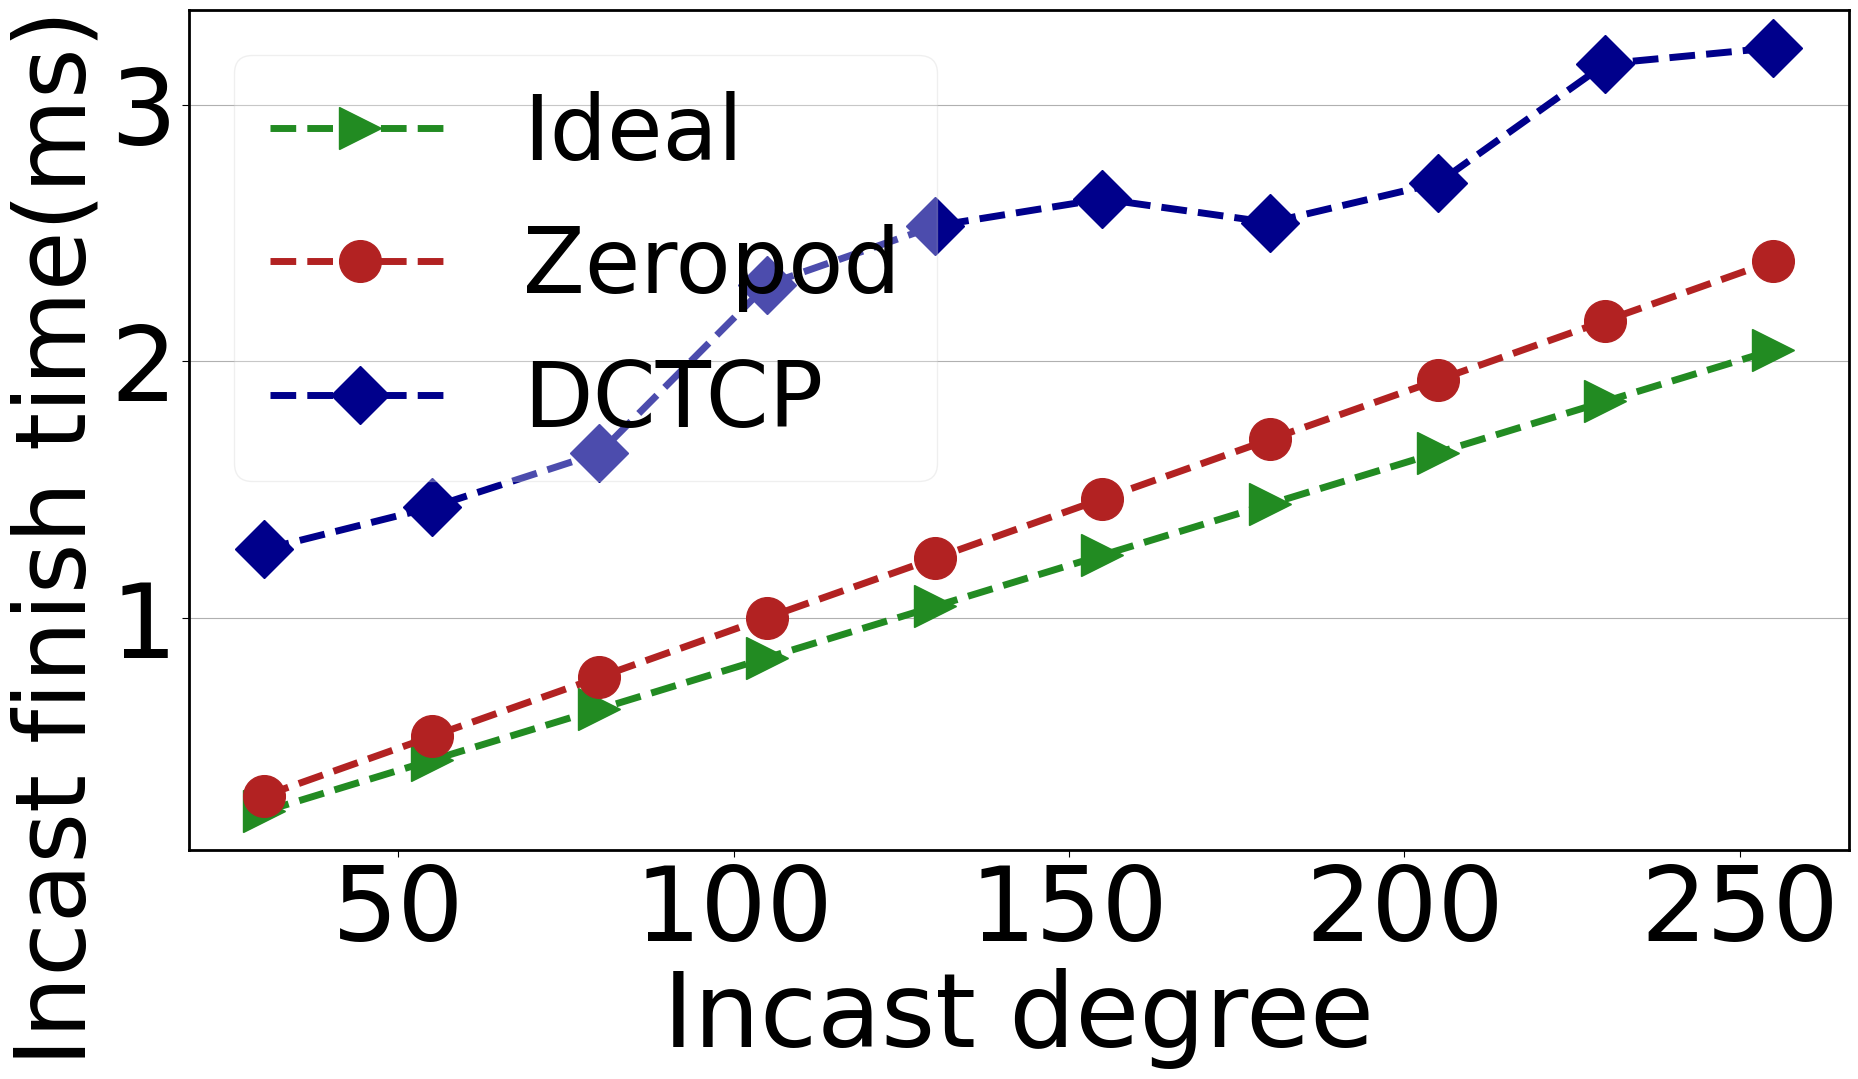

In [22]:
WIDTH = 0.05
def incast_finish_time():
    results = {}
    for i, scheme in enumerate(SCHEMES):
        results[scheme] = []
        for workload in workloads:
            incast_fct = data[scheme][workload]['FCT'][:, 7] # fct
            # print(len(incast_fct))
            incast_finish_time = max(incast_fct)
            results[scheme].append(incast_finish_time*1e3)
    



    fig, ax = plt.subplots(figsize=my_figsize)
    # plt.subplots_adjust(left=0.10, right=0.96, bottom=0.15, top=0.9)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    

    for i, scheme in enumerate(SCHEMES):
        ax.plot(incast_degree, results[SCHEMES[i]], color =colors[i], marker =markers[i], markersize=30, linestyle = '--', linewidth=5, label = labels[i])
    # print(results)
    # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
    # ax.set_ylabel('Goodput\n(normalized)', fontsize=my_fontsize)
    ax.set_ylabel('Incast finish time(ms)       ', fontsize=my_fontsize-5)
    # ax.set_xticks(x_tick)
    # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
    ax.set_xlabel("Incast degree", fontsize=my_fontsize)
    # ax.set_xticklabels(labels, fontsize=my_fontsize)
    ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-10, framealpha=0.3)
    ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
    # ax.set_xticks()
    # ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-5, handlelength = 1.5, borderpad = 0.2,  labelspacing = 0.3, columnspacing = 1.0)

    # plt.xticks(fontsize=my_fontsize-5)
    ax.tick_params(axis='both', which='both', length=5)
    # plt.ylim((0, 250))
    # plt.yticks(np.arange(-1,1.01,0.2), [1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # plt.yticks(np.arange(0,1.01,0.2))
    ax.grid(axis="y")
    
    # plt.yticks(fontsize=my_fontsize-5)
    plt.subplots_adjust(left=0.16, right=0.99, bottom=0.2, top=0.9)
    # plt.savefig('../FIGS/microbenchmarks/incast_finish_time_multipods.pdf', bbox_inches='tight')
colors = ['forestgreen', 'firebrick', 'darkblue']  
markers = ['>', 'o', 'D', 'd']          
labels = ['Ideal', 'Zeropod', 'DCTCP']
incast_finish_time()
plt.savefig(f"../../FIGS/NSDI25-Figures/One-Pod/4. Incast-Finish-Time.pdf")

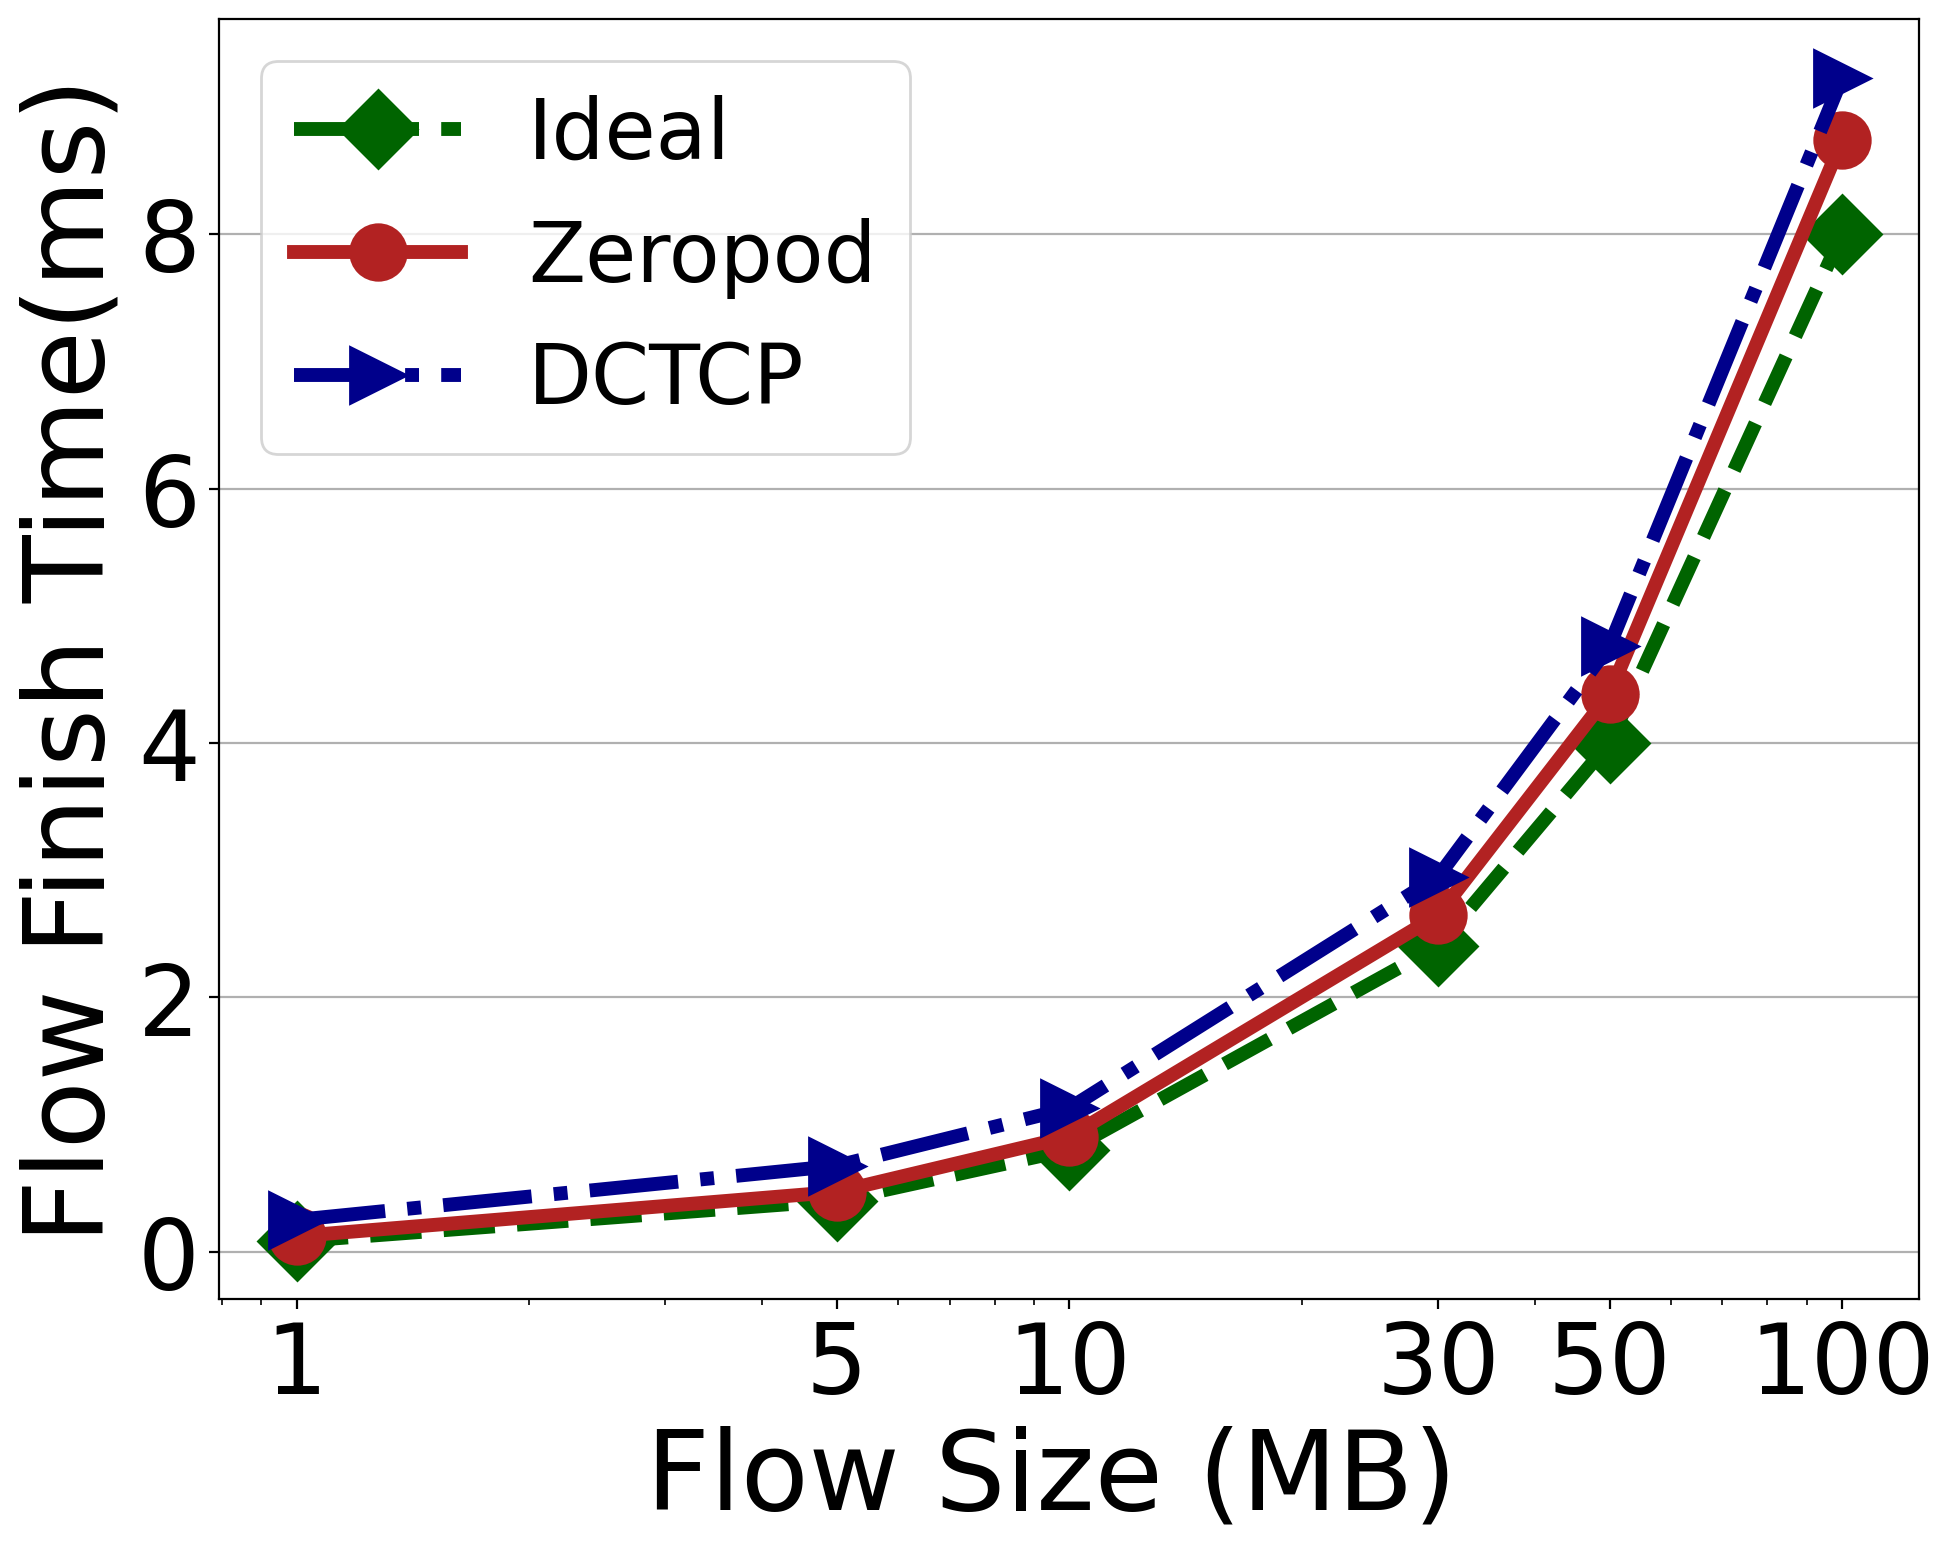

In [4]:
import numpy as np
from matplotlib import pyplot as plt
pattern = 'allreduce_onepod'

schemes = ["../../Ideal/DATA/NSDI25/Onepod/{pattern}".format(pattern=pattern), 
           '../../zeropod-singlepod/DATA/NSDI25/ost=5/{pattern}/ppt_16_topk_16'.format(pattern=pattern), 
           '../../ESN/DATA/NSDI25/singlepod/{pattern}'.format(pattern=pattern)]
# schemes = ['dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/schedule5/permutation/ppt_32_bppn_320_topk_16']

workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100", "permutation_size300", "permutation_size1000"]
workloads = ["allreduce_size1", "allreduce_size5", "allreduce_size10", "allreduce_size30", "allreduce_size50", "allreduce_size100"]
sizes = [1, 5, 10, 30, 50, 100]
myfontsize = 40

# load = 'Pureincast'
load = 'Permutation'
group = 1
colors = ['darkgreen', 'firebrick', 'darkblue']
linestyles = ['dashed', 'solid', 'dashdot']
markers = ['D', 'o', '>']
labels = ['Ideal', 'Zeropod', 'DCTCP']
# data = np.zeros([2 * group, len(workloads)], dtype = float) 
plt.figure(figsize=(10, 8), dpi=200)

for i, scheme in enumerate(schemes): 
    finish_time = []
    for j, workload in enumerate(workloads):
    
        dir_name = scheme + "/DATA_zeropod_" + workload
        # file_name = dir_name + "/GOODPUT.txt"
        # data[i][j] = np.loadtxt(file_name, usecols=(1,))[73]
        file_name = dir_name + "/FCT.txt"
        fct = np.loadtxt(file_name)
        # print(tmp[4:5, :])
        # data[i][j] = np.mean(8*tmp[:, 4:5] / tmp[:,7:8]) / 1e9
        finish_time.append(max(fct[:, 7:8]) * 1e3)

    plt.plot(sizes, finish_time, color = colors[i], marker = markers[i], markersize=20, linestyle = linestyles[i], linewidth=5, label = labels[i])
    plt.xlabel("Flow Size (MB) ", fontsize=myfontsize)
    plt.ylabel(r"Flow Finish Time(ms)", fontsize=myfontsize) 
    # plt.ylabel(r"All-to-all finish time(ms)", fontsize=myfontsize) 
    plt.xscale('log')
    plt.xticks([1, 5, 10, 30, 50, 100], (1, 5, 10, 30, 50, 100), fontsize=myfontsize-5)       
    plt.yticks(fontsize=myfontsize-5)
    plt.grid(axis='y')
    plt.subplots_adjust(left=0.14, right=0.99, bottom=0.15, top=0.95)
    plt.legend(loc = 'upper left', fontsize=myfontsize-10)     
            
plt.savefig(f"../../FIGS/NSDI25-Figures/One-Pod/4. AllReduce-Finish-Time.pdf")

# print(data)


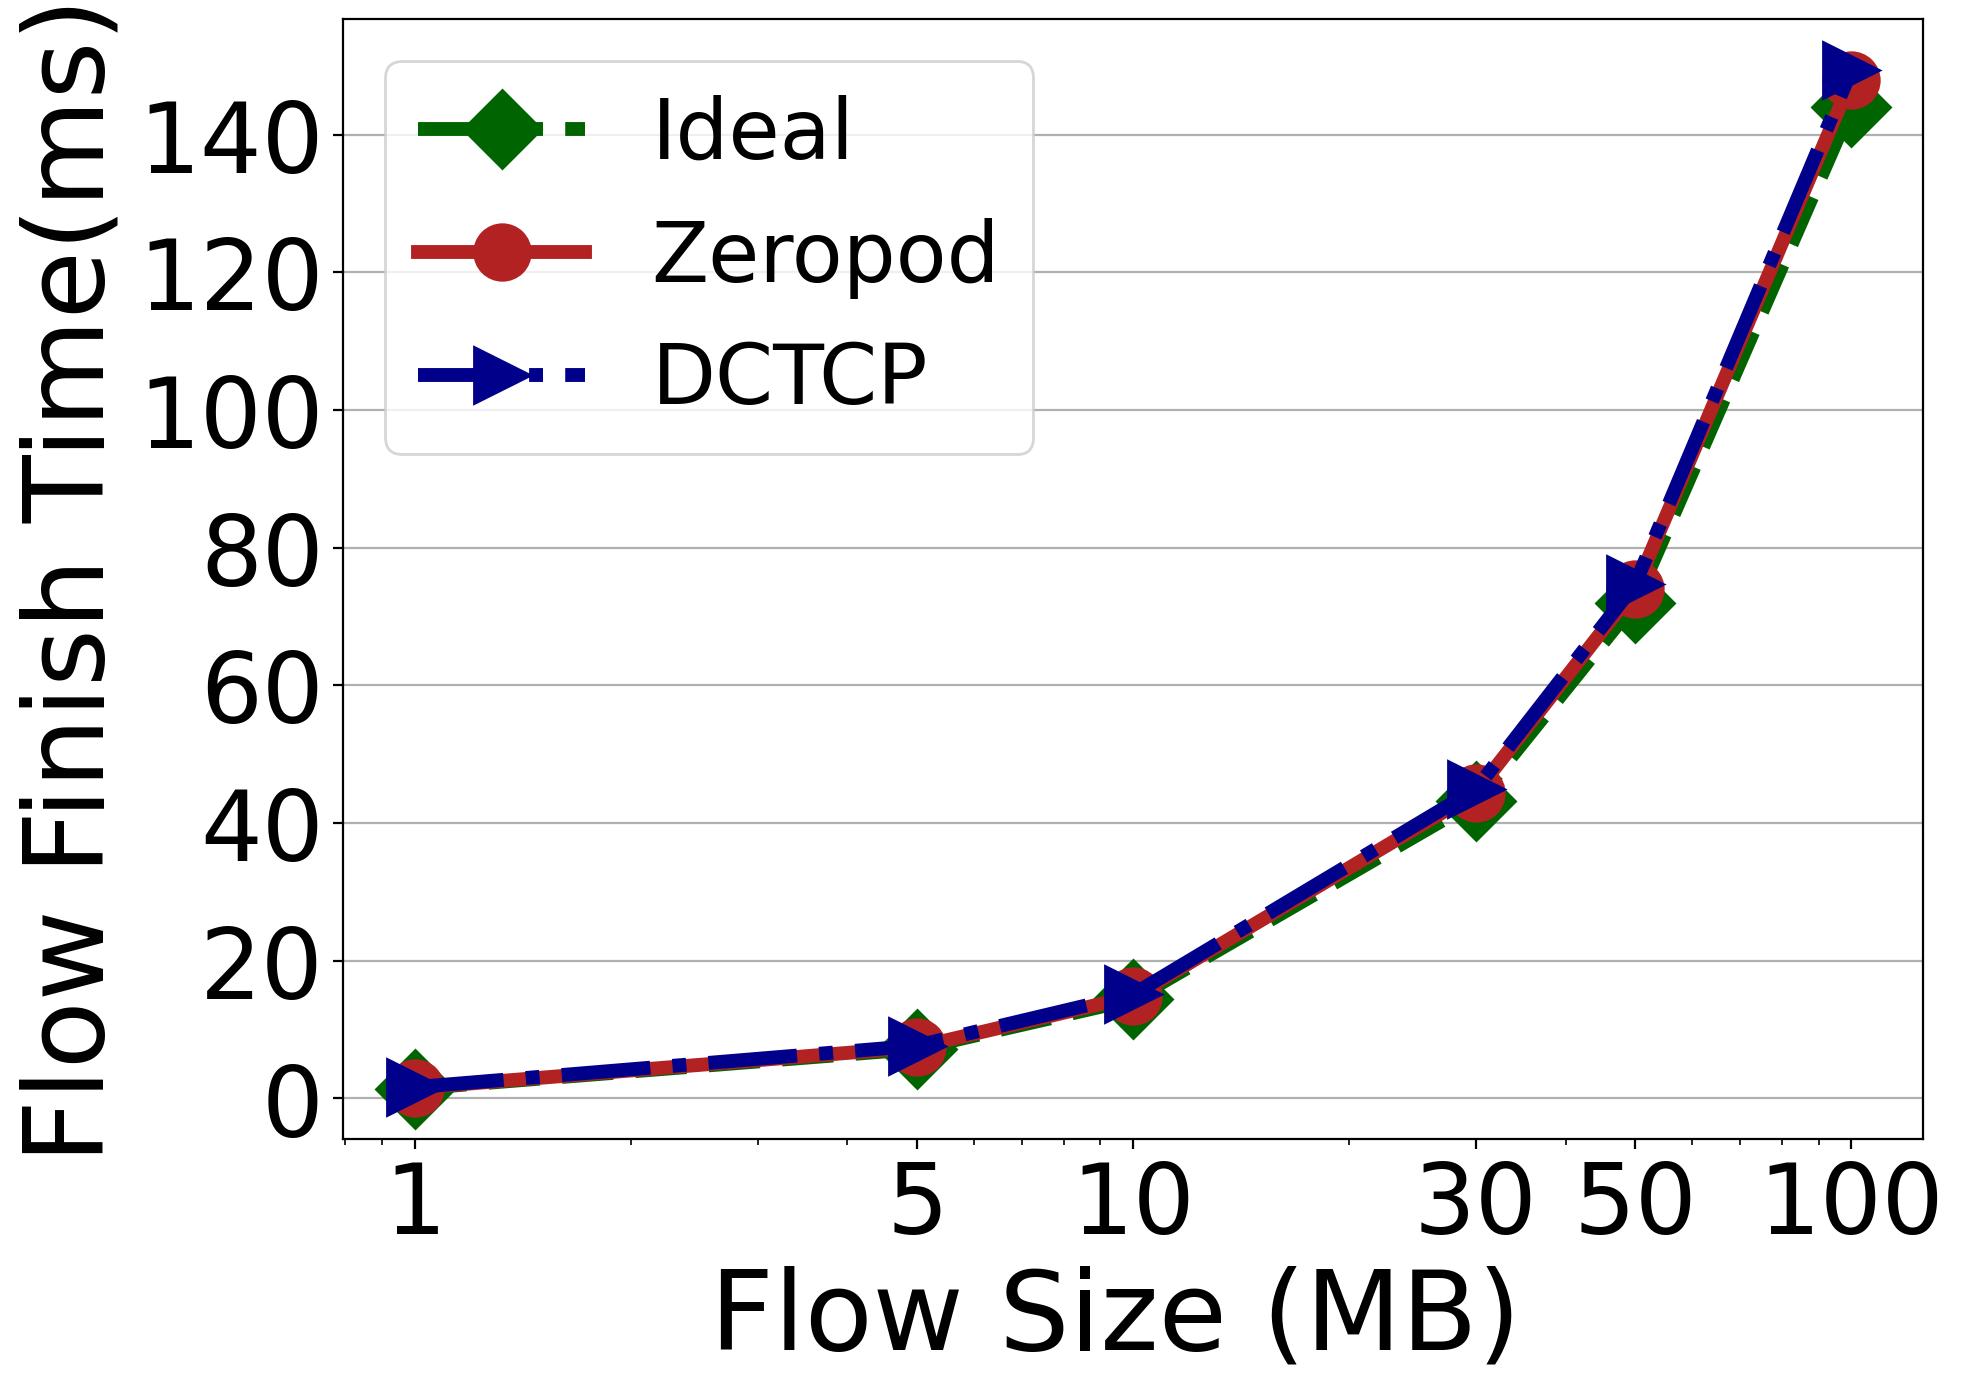

In [26]:
import numpy as np
from matplotlib import pyplot as plt
pattern = 'interrack_alltoall'
schemes = ["../../Ideal/DATA/NSDI25/Onepod/{pattern}".format(pattern=pattern), 
           '../../zeropod-singlepod/DATA/NSDI25/ost=5/{pattern}/ppt_16_topk_16'.format(pattern=pattern), 
           '../../ESN/DATA/NSDI25/singlepod/{pattern}'.format(pattern=pattern)]
# schemes = ['dctcp/multipods_W5/permutation', 'Zeropod/multipods_W5/schedule5/permutation/ppt_32_bppn_320_topk_16']

workloads = ["permutation_size1", "permutation_size3", "permutation_size10", "permutation_size30", "permutation_size100", "permutation_size300", "permutation_size1000"]
workloads = ["allreduce_size1", "allreduce_size5", "allreduce_size10", "allreduce_size30", "allreduce_size50", "allreduce_size100"]
sizes = [1, 5, 10, 30, 50, 100]
myfontsize = 40

# load = 'Pureincast'
load = 'Permutation'
group = 1
colors = ['darkgreen', 'firebrick', 'darkblue']
linestyles = ['dashed', 'solid', 'dashdot']
markers = ['D', 'o', '>']
labels = ['Ideal', 'Zeropod', 'DCTCP']
# data = np.zeros([2 * group, len(workloads)], dtype = float) 
plt.figure(figsize=(10, 8), dpi=200)

for i, scheme in enumerate(schemes): 
    finish_time = []
    for j, workload in enumerate(workloads):
    
        dir_name = scheme + "/DATA_zeropod_" + workload
        # file_name = dir_name + "/GOODPUT.txt"
        # data[i][j] = np.loadtxt(file_name, usecols=(1,))[73]
        file_name = dir_name + "/FCT.txt"
        fct = np.loadtxt(file_name)
        # print(tmp[4:5, :])
        # data[i][j] = np.mean(8*tmp[:, 4:5] / tmp[:,7:8]) / 1e9
        finish_time.append(max(fct[:, 7:8]) * 1e3)
        
    plt.subplots_adjust(left=0.2, right=0.99, bottom=0.2, top=0.9)
    plt.plot(sizes, finish_time, color = colors[i], marker = markers[i], markersize=20, linestyle = linestyles[i], linewidth=5, label = labels[i])
    plt.xlabel("Flow Size (MB) ", fontsize=myfontsize)
    plt.ylabel(r"Flow Finish Time(ms)", fontsize=myfontsize) 
    # plt.ylabel(r"All-to-all finish time(ms)", fontsize=myfontsize) 
    plt.xscale('log')
    plt.xticks([1, 5, 10, 30, 50, 100], (1, 5, 10, 30, 50, 100), fontsize=myfontsize-5)       
    plt.yticks(fontsize=myfontsize-5)
    plt.grid(axis='y')
    plt.legend(loc = 'upper left', fontsize=myfontsize-10)     
            
plt.savefig(f"../../FIGS/NSDI25-Figures/One-Pod/4. Inter-Rack-Alltoall-Finish-Time.pdf")
